In [1]:
# CELL 0 — IMPORT LIBRARY
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import glob
from PIL import Image
from collections import Counter
import matplotlib.image as mpimg
import time
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, Model
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import uniform_filter

print("GPUs:", tf.config.list_physical_devices('GPU'))
print("TensorFlow:", tf.__version__)


2026-05-13 06:20:16.165455: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778653216.392041      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778653216.455672      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778653216.985972      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778653216.986012      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778653216.986014      22 computation_placer.cc:177] computation placer alr

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow: 2.19.0


In [2]:
# CELL 1 — LOAD DATASET (via Add Input, tidak perlu download)
DATA_PATH = "/kaggle/input/datasets/colorlabeilat/seathru-dataset"
print("Dataset path:", DATA_PATH)
print("Scenes:", os.listdir(DATA_PATH))


Dataset path: /kaggle/input/datasets/colorlabeilat/seathru-dataset
Scenes: ['D5', 'D2', 'D4', 'D1', 'D3']


In [3]:
# CELL 2 — CONFIG
SCENES     = ["D1", "D2", "D3", "D4", "D5"]
PATCH_SIZE = 256
BATCH_SIZE = 4      # turun dari 16 -> 4 agar tidak OOM
SEED       = 42

# Batasi steps agar training tidak jalan berhari-hari
TRAIN_STEPS     = 500   # dari ~2760 -> 500
VAL_STEPS       = 100
TEACHER_EPOCHS  = 5     # dari 30 -> 5
STUDENT_EPOCHS  = 5     # dari 50 -> 5

print(f"BATCH_SIZE     : {BATCH_SIZE}")
print(f"TRAIN_STEPS    : {TRAIN_STEPS}")
print(f"TEACHER_EPOCHS : {TEACHER_EPOCHS}")
print(f"STUDENT_EPOCHS : {STUDENT_EPOCHS}")


BATCH_SIZE     : 4
TRAIN_STEPS    : 500
TEACHER_EPOCHS : 5
STUDENT_EPOCHS : 5


In [4]:
# CELL 3 — BUILD IMAGE-DEPTH PAIRS
all_pairs = []

for scene in SCENES:
    base_path = os.path.join(DATA_PATH, scene, scene)
    img_dir   = os.path.join(base_path, "linearPNG")

    if os.path.exists(os.path.join(base_path, "depth")):
        depth_dir = os.path.join(base_path, "depth")
    elif os.path.exists(os.path.join(base_path, "depth_resized")):
        depth_dir = os.path.join(base_path, "depth_resized")
    else:
        print(f"Skipping {scene}: no depth folder")
        continue

    img_files   = sorted(os.listdir(img_dir))
    depth_files = sorted(os.listdir(depth_dir))
    img_dict    = {os.path.splitext(f)[0]: f for f in img_files}
    depth_dict  = {os.path.splitext(f)[0].replace("depth", ""): f for f in depth_files}
    common_keys = sorted(set(img_dict.keys()) & set(depth_dict.keys()))
    print(f"{scene}: {len(common_keys)} matched pairs")

    for key in common_keys:
        all_pairs.append((
            os.path.join(img_dir,   img_dict[key]),
            os.path.join(depth_dir, depth_dict[key])
        ))

print("\nTotal image-depth pairs:", len(all_pairs))


D1: 622 matched pairs
D2: 319 matched pairs
D3: 68 matched pairs
D4: 153 matched pairs
D5: 43 matched pairs

Total image-depth pairs: 1205


In [5]:
# CELL 4 — COMPUTE GLOBAL DEPTH MAX
depth_max_values = []
for _, depth_path in all_pairs:
    depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_max_values.append(np.max(depth))

GLOBAL_DEPTH_MAX = np.max(depth_max_values)
print("GLOBAL_DEPTH_MAX:", GLOBAL_DEPTH_MAX)
np.save("global_depth_max.npy", GLOBAL_DEPTH_MAX)


GLOBAL_DEPTH_MAX: 26.075403


In [6]:
# CELL 5 — IMAGE DIMENSION ANALYSIS
dim_records = []
extensions  = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
image_files = []
for ext in extensions:
    image_files.extend(glob.glob(os.path.join(DATA_PATH, '**', ext), recursive=True))

for img_path in image_files:
    try:
        label = os.path.basename(os.path.dirname(img_path))
        with Image.open(img_path) as img:
            w, h = img.size
            dim_records.append({'label': label, 'width': w, 'height': h,
                                 'aspect_ratio': round(w/h, 3), 'megapixel': round(w*h/1e6, 3)})
    except:
        continue

dim_df = pd.DataFrame(dim_records)
if not dim_df.empty:
    print(f'\n{"Metric":<20} {"Min":>10} {"Median":>10} {"Mean":>10} {"Max":>10}')
    for col in ['width', 'height', 'aspect_ratio', 'megapixel']:
        print(f'{col:<20} {dim_df[col].min():>10.2f} {dim_df[col].median():>10.2f} '
              f'{dim_df[col].mean():>10.2f} {dim_df[col].max():>10.2f}')



Metric                      Min     Median       Mean        Max
width                   2212.00    2400.00    2369.70    2400.00
height                  1476.00    1596.00    1576.66    1596.00
aspect_ratio               1.50       1.50       1.50       1.50
megapixel                  3.27       3.83       3.74       3.83


In [7]:
# CELL 6 — SPLIT BEFORE PATCHING
train_pairs, test_pairs = train_test_split(all_pairs, test_size=0.15, random_state=SEED)
train_pairs, val_pairs  = train_test_split(train_pairs, test_size=0.15, random_state=SEED)

print(f"Train images : {len(train_pairs)}")
print(f"Val images   : {len(val_pairs)}")
print(f"Test images  : {len(test_pairs)}")

np.save("train_pairs.npy", train_pairs)
np.save("val_pairs.npy",   val_pairs)
np.save("test_pairs.npy",  test_pairs)


Train images : 870
Val images   : 154
Test images  : 181


In [8]:
# CELL 7 — SAVE CONFIG
config = {
    "PATCH_SIZE"      : PATCH_SIZE,
    "BATCH_SIZE"      : BATCH_SIZE,
    "GLOBAL_DEPTH_MAX": float(GLOBAL_DEPTH_MAX),
    "SEED"            : SEED
}
np.save("preprocessing_config.npy", config)
print("Config saved!")


Config saved!


In [9]:
# CELL 8 — LOADER RGB + DEPTH + MASK
def load_image_depth(img_file, depth_file):
    img = cv2.imread(img_file, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = img / 65535.0 if img.max() > 255 else img / 255.0
    img = img * 2.0 - 1.0

    depth      = cv2.imread(depth_file, cv2.IMREAD_UNCHANGED).astype(np.float32)
    valid_mask = np.isfinite(depth).astype(np.float32)
    valid_mask[depth <= 0] = 0
    hole_mask  = (depth <= 0).astype(np.uint8)
    if hole_mask.sum() > 0:
        depth = cv2.inpaint(depth, hole_mask, 3, cv2.INPAINT_NS)
    depth = np.clip(depth / GLOBAL_DEPTH_MAX, 0, 1)
    return img, depth, valid_mask

print("Loader siap!")


Loader siap!


In [10]:
# CELL 9 — PATCH GENERATOR
def patch_generator(pairs):
    for img_path, depth_path in pairs:
        result = load_image_depth(img_path, depth_path)
        if result is None:
            continue
        img, depth, mask = result
        h, w = img.shape[:2]
        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                ip = img  [y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                dp = depth[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                mp = mask [y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                if np.mean(mp) < 0.05:
                    continue
                yield ip, dp, mp

print("Patch generator siap!")


Patch generator siap!


In [11]:
# CELL 10 — TF.DATA PIPELINE
# train_ds pakai .repeat() -> WAJIB pakai TRAIN_STEPS saat training!
sig = (
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE),    dtype=tf.float32),
    tf.TensorSpec(shape=(PATCH_SIZE, PATCH_SIZE),    dtype=tf.float32),
)

@tf.function
def augment(rgb, depth, mask):
    combined = tf.concat([rgb, depth[..., None], mask[..., None]], axis=-1)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_left_right(combined)
    if tf.random.uniform(()) > 0.5:
        combined = tf.image.flip_up_down(combined)
    combined = tf.image.rot90(combined, tf.random.uniform([], 0, 4, dtype=tf.int32))
    return combined[..., :3], combined[..., 3], combined[..., 4]

train_ds = (tf.data.Dataset.from_generator(lambda: patch_generator(train_pairs), output_signature=sig)
    .shuffle(200).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_generator(lambda: patch_generator(val_pairs), output_signature=sig)
    .batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_generator(lambda: patch_generator(test_pairs), output_signature=sig)
    .batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE))

for rgb, depth, mask in train_ds.take(1):
    print("RGB   :", rgb.shape, "| range:", float(rgb.numpy().min()), "~", float(rgb.numpy().max()))
    print("Depth :", depth.shape)
    print("Mask  :", mask.shape)
print("TF.DATA pipeline ready!")


I0000 00:00:1778653491.311285      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778653491.317529      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


RGB   : (4, 256, 256, 3) | range: -0.99920654296875 ~ -0.35771727561950684
Depth : (4, 256, 256)
Mask  : (4, 256, 256)
TF.DATA pipeline ready!


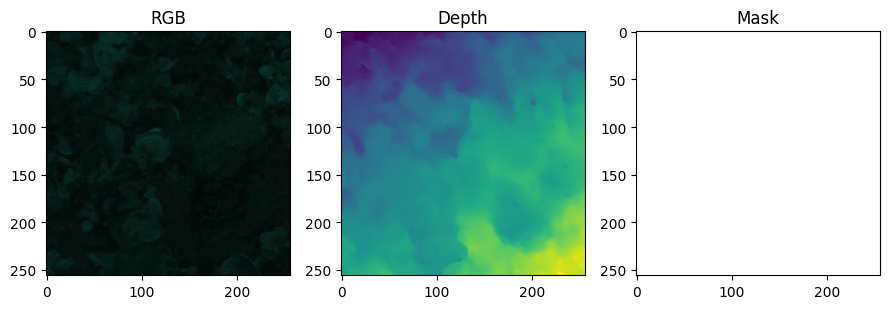

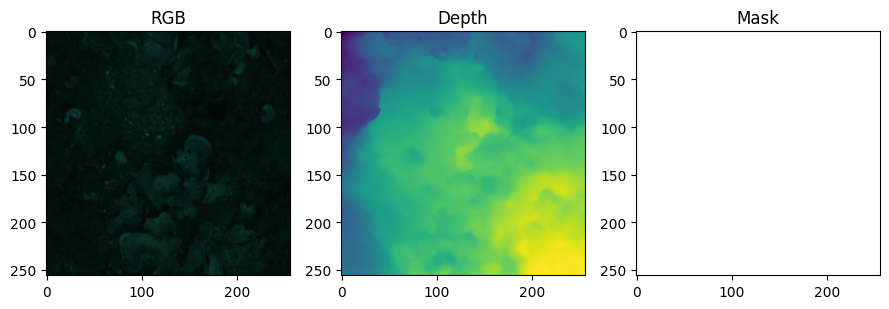

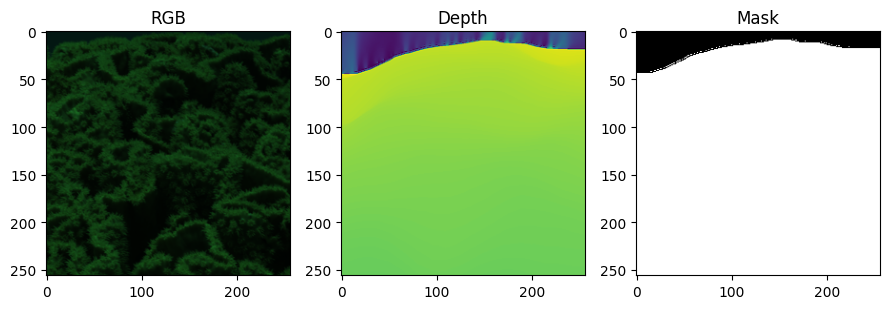

In [12]:
# CELL 11 — VISUALIZATION
for rgb_batch, depth_batch, mask_batch in train_ds.take(1):
    for i in range(min(3, BATCH_SIZE)):
        plt.figure(figsize=(9, 3))
        plt.subplot(1,3,1); plt.imshow((rgb_batch[i].numpy()+1)/2); plt.title("RGB")
        plt.subplot(1,3,2); plt.imshow(depth_batch[i].numpy(), cmap="viridis"); plt.title("Depth")
        plt.subplot(1,3,3); plt.imshow(mask_batch[i].numpy(), cmap="gray", vmin=0, vmax=1); plt.title("Mask")
        plt.tight_layout(); plt.show()


# Modelling

In [13]:
# CELL 12 — FIX TF LAYOUT OPTIMIZER
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
tf.config.optimizer.set_experimental_options({"layout_optimizer": False})
print("TF optimizer fixed!")


TF optimizer fixed!


In [14]:
# CELL 13 — UGAN TEACHER MODEL
def ugan_generator(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    def encoder_block(x, filters, bn=True):
        x = layers.Conv2D(filters, 4, strides=2, padding='same',
                          data_format='channels_last', use_bias=not bn)(x)
        if bn:
            x = layers.BatchNormalization(axis=-1)(x)
        return layers.LeakyReLU(0.2)(x)

    def decoder_block(x, skip, filters, dropout=False):
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same',
                                   data_format='channels_last', use_bias=False)(x)
        x = layers.BatchNormalization(axis=-1)(x)
        x = layers.ReLU()(x)
        if dropout:
            x = layers.SpatialDropout2D(0.5, data_format='channels_last')(x)
        return layers.Concatenate(axis=-1)([x, skip])

    inp = layers.Input(shape=input_shape)
    e1 = encoder_block(inp, 64,  bn=False)
    e2 = encoder_block(e1,  128)
    e3 = encoder_block(e2,  256)
    e4 = encoder_block(e3,  512)
    e5 = encoder_block(e4,  512)
    e6 = encoder_block(e5,  512)
    e7 = encoder_block(e6,  512)
    e8 = encoder_block(e7,  512)
    d1 = decoder_block(e8, e7, 512, dropout=True)
    d2 = decoder_block(d1, e6, 512, dropout=True)
    d3 = decoder_block(d2, e5, 512, dropout=True)
    d4 = decoder_block(d3, e4, 512)
    d5 = decoder_block(d4, e3, 256)
    d6 = decoder_block(d5, e2, 128)
    d7 = decoder_block(d6, e1,  64)
    out = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  data_format='channels_last', activation='tanh')(d7)
    return Model(inp, out, name="UGAN_Generator")


def ugan_discriminator(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    def d_block(x, filters, strides=2, bn=True):
        x = layers.Conv2D(filters, 4, strides=strides, padding='same',
                          data_format='channels_last', use_bias=not bn)(x)
        if bn:
            x = layers.BatchNormalization(axis=-1)(x)
        return layers.LeakyReLU(0.2)(x)

    inp  = layers.Input(shape=input_shape)
    targ = layers.Input(shape=input_shape)
    x = layers.Concatenate(axis=-1)([inp, targ])
    x = d_block(x,  64, bn=False)
    x = d_block(x, 128)
    x = d_block(x, 256)
    x = d_block(x, 512, strides=1)
    x = layers.Conv2D(1, 4, padding='same', data_format='channels_last')(x)
    return Model([inp, targ], x, name="UGAN_Discriminator")


teacher_gen  = ugan_generator()
teacher_disc = ugan_discriminator()

print(f"UGAN Generator     : {teacher_gen.count_params():,} params")
print(f"UGAN Discriminator : {teacher_disc.count_params():,} params")


UGAN Generator     : 54,425,923 params
UGAN Discriminator : 2,770,497 params


In [15]:
# CELL 14 — GHOSTNET-UNET STUDENT MODEL
def ghost_module(x, out_channels, ratio=2, kernel_size=1, dw_size=3):
    init_channels  = int(np.ceil(out_channels / ratio))
    ghost_channels = out_channels - init_channels
    primary = layers.Conv2D(init_channels, kernel_size, padding='same', use_bias=False)(x)
    primary = layers.BatchNormalization()(primary)
    primary = layers.ReLU()(primary)
    ghost   = layers.DepthwiseConv2D(dw_size, padding='same', use_bias=False)(primary)
    ghost   = layers.BatchNormalization()(ghost)
    ghost   = layers.ReLU()(ghost)
    if ghost_channels < init_channels:
        ghost = ghost[..., :ghost_channels]
    return layers.Concatenate()([primary, ghost])


def ghost_encoder_block(x, filters, pool=True):
    x    = ghost_module(x, filters)
    x    = ghost_module(x, filters)
    skip = x
    if pool:
        x = layers.MaxPooling2D(2)(x)
    return x, skip


def ghost_decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = ghost_module(x, filters)
    x = ghost_module(x, filters)
    return x


def ghost_unet_student(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    inp      = layers.Input(shape=input_shape)
    x, s1   = ghost_encoder_block(inp,  32)
    x, s2   = ghost_encoder_block(x,    64)
    x, s3   = ghost_encoder_block(x,   128)
    x, s4   = ghost_encoder_block(x,   256)
    x, _    = ghost_encoder_block(x,   512, pool=False)
    x       = ghost_decoder_block(x, s4, 256)
    x       = ghost_decoder_block(x, s3, 128)
    x       = ghost_decoder_block(x, s2,  64)
    x       = ghost_decoder_block(x, s1,  32)
    out     = layers.Conv2D(3, 1, activation='tanh')(x)
    return Model(inp, out, name="GhostNet_UNet_Student")


student_model = ghost_unet_student()
print(f"Student (GhostNet-UNet) : {student_model.count_params():,} params")
print(f"Teacher (UGAN)          : {teacher_gen.count_params():,} params")
print(f"Rasio kompresi          : {teacher_gen.count_params()/student_model.count_params():.1f}x")


Student (GhostNet-UNet) : 1,114,163 params
Teacher (UGAN)          : 54,425,923 params
Rasio kompresi          : 48.8x


In [16]:
# CELL 15 — FUNIEGAN BASELINE MODEL
def funiegan_generator(input_shape=(PATCH_SIZE, PATCH_SIZE, 3)):
    def enc(x, f, norm=True):
        x = layers.Conv2D(f, 4, strides=2, padding='same',
                          data_format='channels_last', use_bias=not norm)(x)
        if norm:
            x = layers.BatchNormalization(axis=-1)(x)
        return layers.LeakyReLU(0.2)(x)

    def dec(x, skip, f, drop=False):
        x = layers.Conv2DTranspose(f, 4, strides=2, padding='same',
                                   data_format='channels_last', use_bias=False)(x)
        x = layers.BatchNormalization(axis=-1)(x)
        x = layers.ReLU()(x)
        if drop:
            x = layers.SpatialDropout2D(0.5, data_format='channels_last')(x)
        return layers.Concatenate(axis=-1)([x, skip])

    inp = layers.Input(shape=input_shape)
    e1  = enc(inp, 32, norm=False)
    e2  = enc(e1,  64)
    e3  = enc(e2, 128)
    e4  = enc(e3, 256)
    e5  = enc(e4, 256)
    d1  = dec(e5, e4, 256, drop=True)
    d2  = dec(d1, e3, 128)
    d3  = dec(d2, e2,  64)
    d4  = dec(d3, e1,  32)
    out = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  data_format='channels_last', activation='tanh')(d4)
    return Model(inp, out, name="FUnIE_GAN")


baseline_model = funiegan_generator()
print(f"FUnIE-GAN params : {baseline_model.count_params():,}")
print("\n=== Perbandingan Arsitektur ===")
print(f"{'Model':<25} {'Parameter':>12}")
print("-" * 40)
print(f"{'UGAN (Teacher)':<25} {teacher_gen.count_params():>12,}")
print(f"{'FUnIE-GAN (Baseline)':<25} {baseline_model.count_params():>12,}")
print(f"{'GhostNet-UNet (Student)':<25} {student_model.count_params():>12,}")


FUnIE-GAN params : 4,170,915

=== Perbandingan Arsitektur ===
Model                        Parameter
----------------------------------------
UGAN (Teacher)              54,425,923
FUnIE-GAN (Baseline)         4,170,915
GhostNet-UNet (Student)      1,114,163


In [17]:
# CELL 16 — LOSS FUNCTIONS
ALPHA = 0.5
BETA  = 0.3
GAMMA = 0.2

def l1_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def ssim_loss(y_true, y_pred):
    y_true = (y_true + 1.0) / 2.0
    y_pred = (y_pred + 1.0) / 2.0
    return 1.0 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def pixel_loss(gt, student_out):
    return 0.7 * l1_loss(gt, student_out) + 0.3 * ssim_loss(gt, student_out)

def distillation_loss(teacher_out, student_out):
    return l1_loss(teacher_out, student_out)

def total_student_loss(gt, teacher_out, student_out, alpha=ALPHA, beta=BETA, gamma=GAMMA):
    L_distill    = distillation_loss(teacher_out, student_out)
    L_pixel      = pixel_loss(gt, student_out)
    L_perceptual = l1_loss(
        tf.image.sobel_edges(teacher_out),
        tf.image.sobel_edges(student_out)
    )
    total = alpha * L_distill + beta * L_pixel + gamma * L_perceptual
    return total, L_distill, L_pixel, L_perceptual

print(f"Loss functions siap. α={ALPHA} β={BETA} γ={GAMMA}")


Loss functions siap. α=0.5 β=0.3 γ=0.2


In [18]:
# CELL 17 — TRAIN TEACHER (UGAN)
# train_ds pakai .repeat() -> loop manual pakai TRAIN_STEPS!
teacher_gen_opt  = keras.optimizers.Adam(2e-4, beta_1=0.5)
teacher_disc_opt = keras.optimizers.Adam(2e-4, beta_1=0.5)
bce_loss_fn      = keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA_L1        = 100

_train_sig = [
    tf.TensorSpec(shape=(None, PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None, PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
]

@tf.function(input_signature=_train_sig)
def train_teacher_step(degraded, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake     = teacher_gen(degraded, training=True)
        real_out = teacher_disc([degraded, target], training=True)
        fake_out = teacher_disc([degraded, fake],   training=True)
        disc_loss = (bce_loss_fn(tf.ones_like(real_out),  real_out) +
                     bce_loss_fn(tf.zeros_like(fake_out), fake_out)) * 0.5
        gen_loss  = (bce_loss_fn(tf.ones_like(fake_out), fake_out) +
                     tf.reduce_mean(tf.abs(target - fake)) * LAMBDA_L1)

    disc_grads = disc_tape.gradient(disc_loss, teacher_disc.trainable_variables)
    gen_grads  = gen_tape.gradient(gen_loss,   teacher_gen.trainable_variables)
    teacher_disc_opt.apply_gradients(zip(disc_grads, teacher_disc.trainable_variables))
    teacher_gen_opt.apply_gradients(zip(gen_grads,   teacher_gen.trainable_variables))
    return gen_loss, disc_loss


print("Mulai training UGAN Teacher...")
best_teacher_loss = float('inf')
teacher_history   = {'gen_loss': [], 'disc_loss': []}

for epoch in range(TEACHER_EPOCHS):
    gen_losses, disc_losses = [], []
    for step, (degraded, depth, mask) in enumerate(train_ds):
        if step >= TRAIN_STEPS:
            break   # WAJIB: stop karena .repeat() infinite
        degraded = tf.cast(degraded, tf.float32)
        target   = tf.cast(degraded, tf.float32)   # pseudo-GT
        g_loss, d_loss = train_teacher_step(degraded, target)
        gen_losses.append(float(g_loss))
        disc_losses.append(float(d_loss))

    avg_gen  = float(np.mean(gen_losses))
    avg_disc = float(np.mean(disc_losses))
    teacher_history['gen_loss'].append(avg_gen)
    teacher_history['disc_loss'].append(avg_disc)
    print(f"Epoch {epoch+1}/{TEACHER_EPOCHS} | Gen: {avg_gen:.4f} | Disc: {avg_disc:.4f}")

    if avg_gen < best_teacher_loss:
        best_teacher_loss = avg_gen
        teacher_gen.save_weights("teacher_best.weights.h5")
        print("  => Tersimpan!")

print("\nTeacher training selesai!")


Mulai training UGAN Teacher...


I0000 00:00:1778653516.156486      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch 1/5 | Gen: 6.8268 | Disc: 0.3849
  => Tersimpan!
Epoch 2/5 | Gen: 3.1735 | Disc: 0.6089
  => Tersimpan!
Epoch 3/5 | Gen: 3.0512 | Disc: 0.5621
  => Tersimpan!
Epoch 4/5 | Gen: 4.1499 | Disc: 0.4226
Epoch 5/5 | Gen: 2.6914 | Disc: 0.5821
  => Tersimpan!

Teacher training selesai!


In [19]:
# CELL 18 — TRAIN STUDENT (Knowledge Distillation)
# Load & freeze teacher
teacher_gen.load_weights("teacher_best.weights.h5")
teacher_gen.trainable = False
print("Teacher di-freeze.")

student_opt    = keras.optimizers.Adam(1e-4, beta_1=0.9)
best_val_loss  = float('inf')
student_history = {'total': [], 'distill': [], 'pixel': [], 'perceptual': []}

_student_sig = [
    tf.TensorSpec(shape=(None, PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(None, PATCH_SIZE, PATCH_SIZE, 3), dtype=tf.float32),
]

@tf.function(input_signature=_student_sig)
def train_student_step(degraded, gt):
    teacher_out = teacher_gen(degraded, training=False)
    with tf.GradientTape() as tape:
        student_out = student_model(degraded, training=True)
        total, L_dist, L_pix, L_perc = total_student_loss(gt, teacher_out, student_out)
    grads = tape.gradient(total, student_model.trainable_variables)
    student_opt.apply_gradients(zip(grads, student_model.trainable_variables))
    return total, L_dist, L_pix, L_perc


print("Mulai Knowledge Distillation Student...")
for epoch in range(STUDENT_EPOCHS):
    totals, dists, pixs, percs = [], [], [], []

    for step, (degraded, depth, mask) in enumerate(train_ds):
        if step >= TRAIN_STEPS:
            break   # WAJIB: stop karena .repeat() infinite
        gt = tf.cast(degraded, tf.float32)
        t, d, p, perc = train_student_step(tf.cast(degraded, tf.float32), gt)
        totals.append(float(t)); dists.append(float(d))
        pixs.append(float(p));   percs.append(float(perc))

    # Validation
    val_losses = []
    for step, (degraded_v, _, _) in enumerate(val_ds):
        if step >= VAL_STEPS:
            break
        teacher_v = teacher_gen(degraded_v, training=False)
        student_v = student_model(degraded_v, training=False)
        vl, _, _, _ = total_student_loss(degraded_v, teacher_v, student_v)
        val_losses.append(float(vl))

    avg_total = np.mean(totals)
    avg_val   = np.mean(val_losses)
    student_history['total'].append(avg_total)
    print(f"Epoch {epoch+1}/{STUDENT_EPOCHS} | Total: {avg_total:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        student_model.save_weights("student_best.weights.h5")
        print("  => Tersimpan!")

print("\nStudent training selesai!")


Teacher di-freeze.
Mulai Knowledge Distillation Student...
Epoch 1/5 | Total: 0.3975 | Val: 0.1646
  => Tersimpan!
Epoch 2/5 | Total: 0.0791 | Val: 0.0795
  => Tersimpan!
Epoch 3/5 | Total: 0.0459 | Val: 0.0553
  => Tersimpan!
Epoch 4/5 | Total: 0.0386 | Val: 0.0473
  => Tersimpan!
Epoch 5/5 | Total: 0.0372 | Val: 0.0451
  => Tersimpan!

Student training selesai!


In [20]:
# CELL 19 — EVALUATION METRICS
from scipy.ndimage import uniform_filter

def compute_uciqe(img_bgr):
    c1, c2, c3 = 0.4680, 0.2745, 0.2576
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L = img_lab[:,:,0] / 255.0
    A = img_lab[:,:,1]
    B = img_lab[:,:,2]
    chroma   = np.sqrt(A**2 + B**2)
    sigma_c  = np.std(chroma)
    L_sorted = np.sort(L.flatten())
    con_l    = np.mean(L_sorted[int(0.99*len(L_sorted)):]) - np.mean(L_sorted[:int(0.01*len(L_sorted))+1])
    mu_s     = np.mean(chroma / (L + 1e-6))
    return float(c1*sigma_c + c2*con_l + c3*mu_s)


def compute_niqe(img_gray, patch_size=7):
    mu    = uniform_filter(img_gray, patch_size)
    mu_sq = uniform_filter(img_gray**2, patch_size)
    sigma = np.sqrt(np.abs(mu_sq - mu**2) + 1e-6)
    mscn  = (img_gray - mu) / (sigma + 1e-6)
    return float(np.var(mscn) + np.abs(np.mean(np.abs(mscn)) - 0.1) * 5)


def evaluate_image(orig_np, enhanced_np):
    orig_u8 = (np.clip(orig_np,     0, 1) * 255).astype(np.uint8)
    enh_u8  = (np.clip(enhanced_np, 0, 1) * 255).astype(np.uint8)
    enh_bgr = cv2.cvtColor(enh_u8, cv2.COLOR_RGB2BGR)
    enh_gray = cv2.cvtColor(enh_u8, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    return {
        'UCIQE': compute_uciqe(enh_bgr),
        'NIQE' : compute_niqe(enh_gray),
        'PSNR' : psnr(orig_np, enhanced_np, data_range=1.0),
        'SSIM' : ssim(orig_np, enhanced_np, data_range=1.0, channel_axis=-1)
    }

print("Metrik evaluasi siap: UCIQE, NIQE, PSNR, SSIM")


Metrik evaluasi siap: UCIQE, NIQE, PSNR, SSIM


In [21]:
# CELL 20 — EVALUASI SEMUA MODEL
teacher_gen.load_weights("teacher_best.weights.h5")
student_model.load_weights("student_best.weights.h5")

results = {
    'Input (Degraded)'   : {'UCIQE': [], 'NIQE': [], 'PSNR': [], 'SSIM': []},
    'UGAN (Teacher)'     : {'UCIQE': [], 'NIQE': [], 'PSNR': [], 'SSIM': []},
    'FUnIE-GAN (Base)'   : {'UCIQE': [], 'NIQE': [], 'PSNR': [], 'SSIM': []},
    'GhostNet (Student)' : {'UCIQE': [], 'NIQE': [], 'PSNR': [], 'SSIM': []},
}

n_samples    = 50
sample_count = 0

for batch in test_ds:
    if sample_count >= n_samples:
        break
    degraded_batch, _, _ = batch
    teacher_out  = teacher_gen(degraded_batch,   training=False).numpy()
    student_out  = student_model(degraded_batch, training=False).numpy()
    baseline_out = baseline_model(degraded_batch, training=False).numpy()

    for i in range(len(degraded_batch)):
        if sample_count >= n_samples:
            break
        orig = (degraded_batch[i].numpy() + 1.0) / 2.0
        t    = (teacher_out[i]   + 1.0) / 2.0
        s    = (student_out[i]   + 1.0) / 2.0
        b    = (baseline_out[i]  + 1.0) / 2.0

        for metric in ['UCIQE', 'NIQE', 'PSNR', 'SSIM']:
            results['Input (Degraded)'][metric].append(evaluate_image(orig, orig)[metric])
            results['UGAN (Teacher)'][metric].append(evaluate_image(orig, t)[metric])
            results['FUnIE-GAN (Base)'][metric].append(evaluate_image(orig, b)[metric])
            results['GhostNet (Student)'][metric].append(evaluate_image(orig, s)[metric])
        sample_count += 1

eval_summary = {
    m: {k: {'mean': np.mean(v), 'std': np.std(v)} for k, v in metrics.items()}
    for m, metrics in results.items()
}

print("\n" + "═"*75)
print(f"{'Model':<25} {'UCIQE↑':>10} {'NIQE↓':>10} {'PSNR↑':>10} {'SSIM↑':>10}")
print("─"*75)
for model_name, metrics in eval_summary.items():
    print(f"{model_name:<25} {metrics['UCIQE']['mean']:>10.4f} {metrics['NIQE']['mean']:>10.4f} "
          f"{metrics['PSNR']['mean']:>10.2f} {metrics['SSIM']['mean']:>10.4f}")
print("═"*75)



═══════════════════════════════════════════════════════════════════════════
Model                         UCIQE↑      NIQE↓      PSNR↑      SSIM↑
───────────────────────────────────────────────────────────────────────────
Input (Degraded)           1709.1379     3.1294        inf     1.0000
UGAN (Teacher)             1857.3738     3.6674      38.29     0.9012
FUnIE-GAN (Base)             95.7094     5.2362       6.83     0.0679
GhostNet (Student)        345606.2932     3.2112      31.74     0.9323
═══════════════════════════════════════════════════════════════════════════


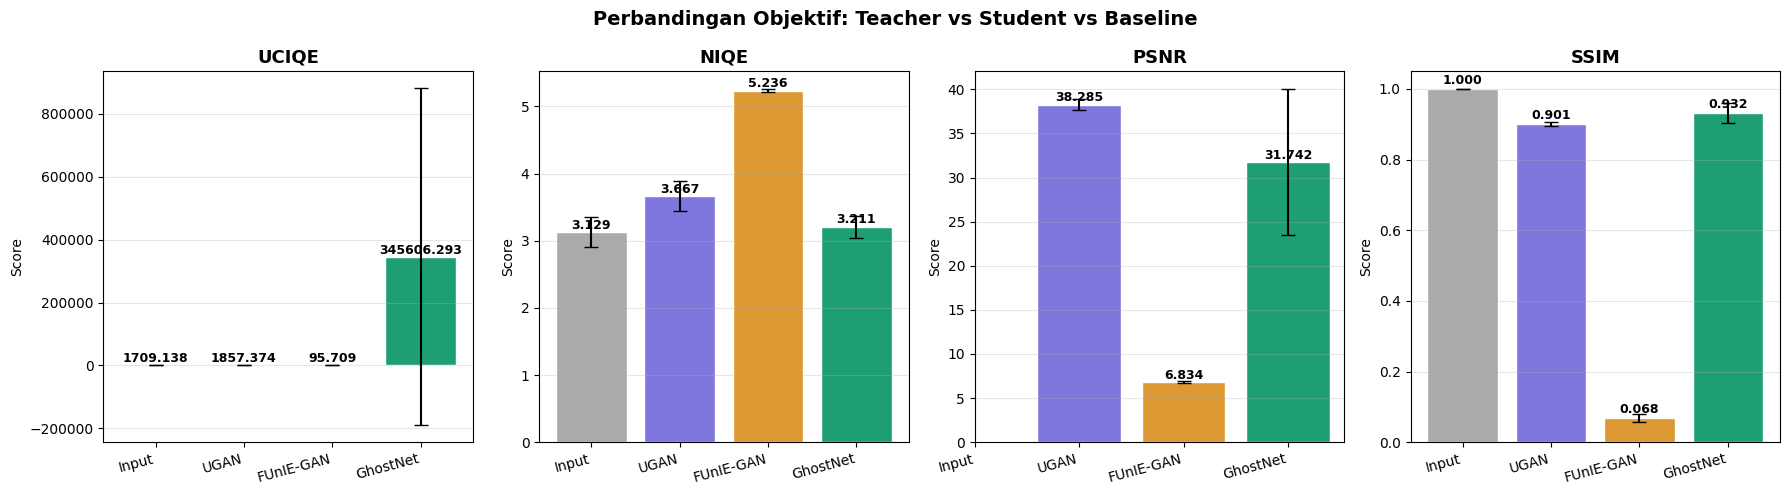

In [22]:
# CELL 21 — CHART EVALUASI
models  = list(eval_summary.keys())
metrics = ['UCIQE', 'NIQE', 'PSNR', 'SSIM']
colors  = ['#AAAAAA', '#7F77DD', '#DD9933', '#1D9E75']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    means = [eval_summary[m][metric]['mean'] for m in models]
    stds  = [eval_summary[m][metric]['std']  for m in models]
    bars  = ax.bar(models, means, yerr=stds, color=colors, capsize=5, edgecolor='white')
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.split(' ')[0] for m in models], rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Perbandingan Objektif: Teacher vs Student vs Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


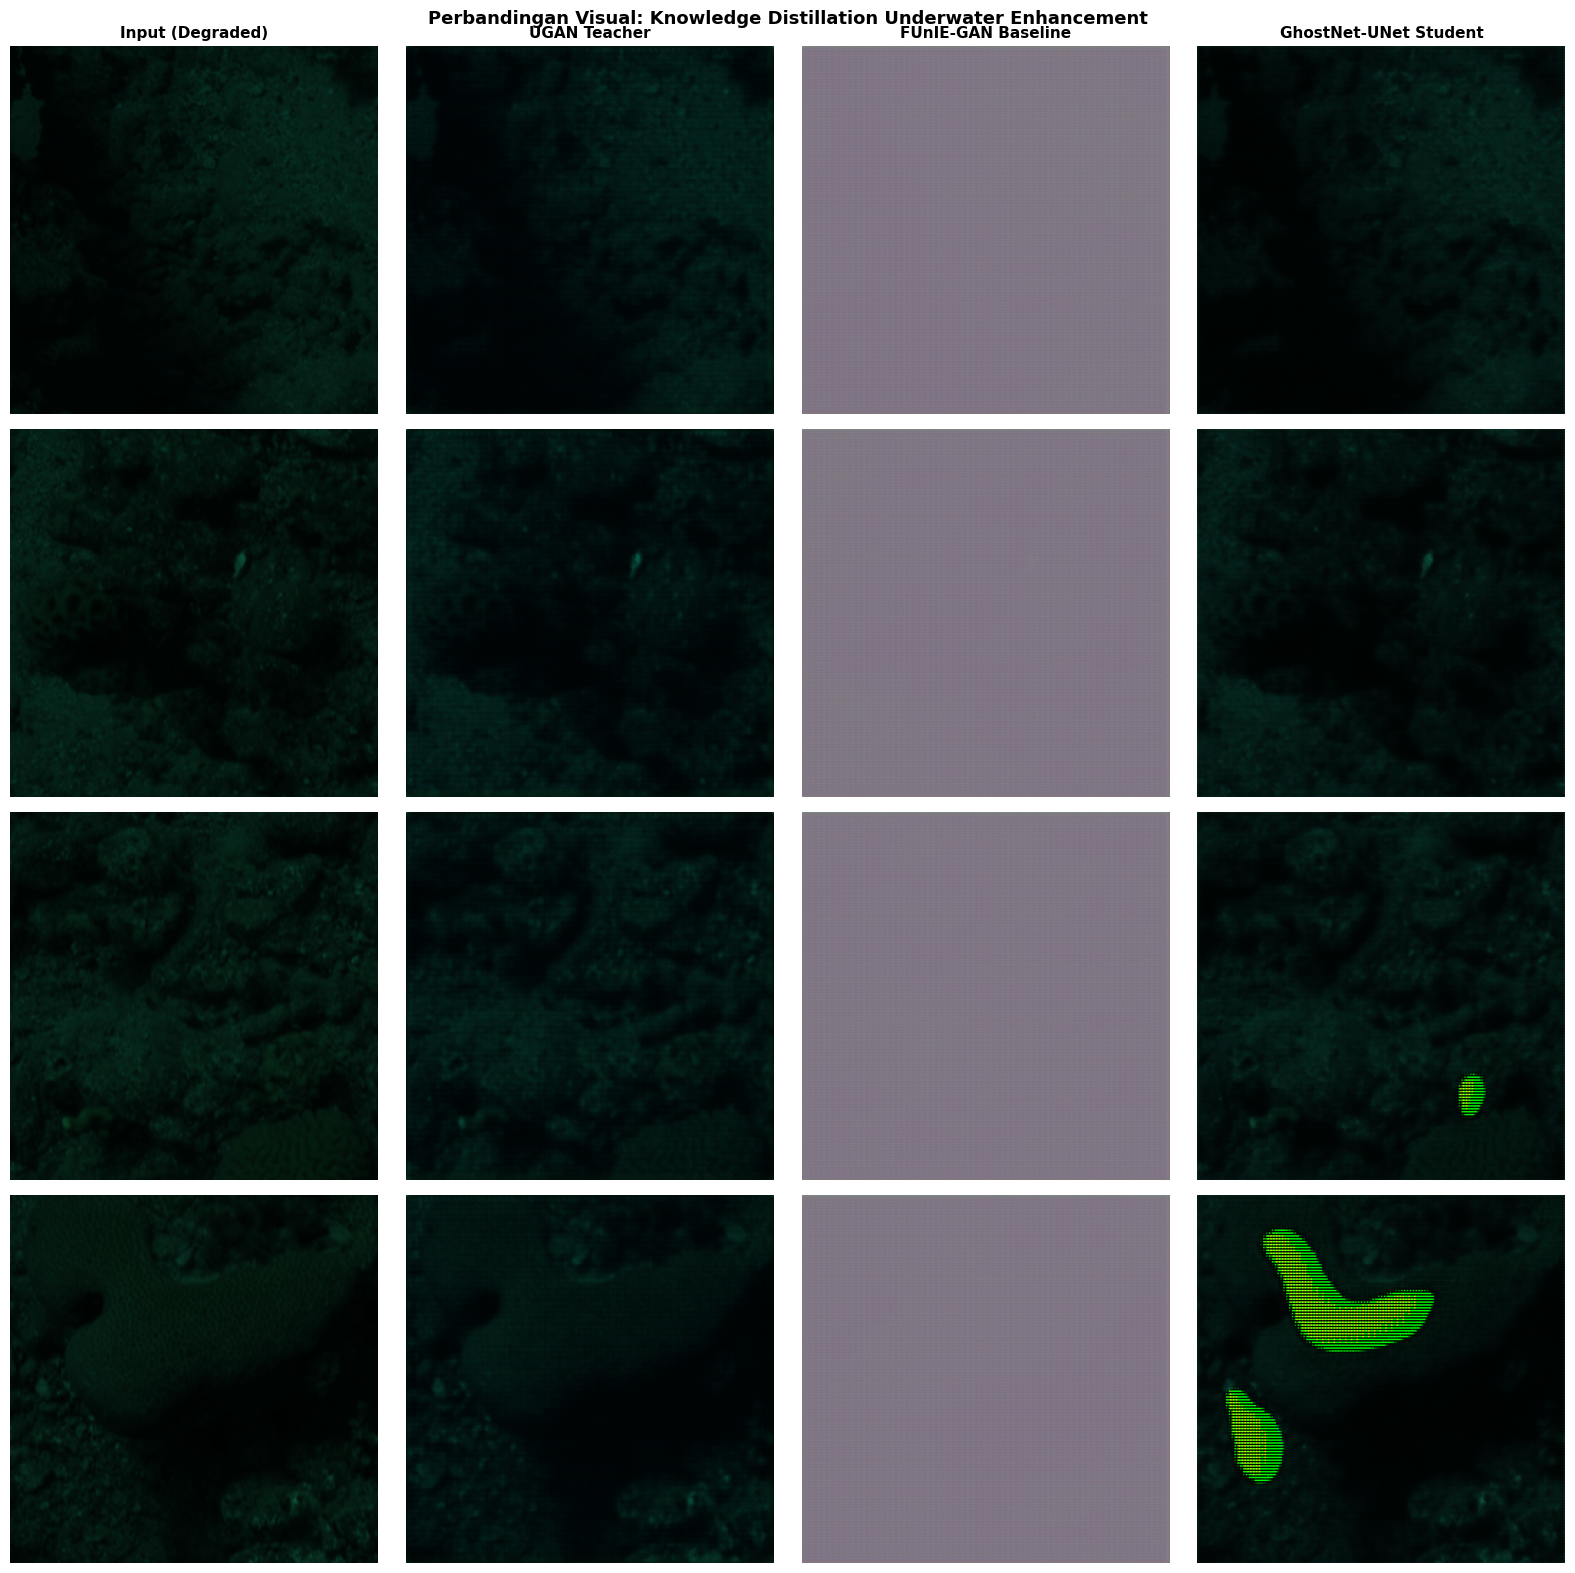

In [23]:
# CELL 22 — VISUALISASI BEFORE vs AFTER (4 kolom)
n_samples = 4
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4*n_samples))
col_titles = ['Input (Degraded)', 'UGAN Teacher', 'FUnIE-GAN Baseline', 'GhostNet-UNet Student']

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontweight='bold', fontsize=11)

sample_idx = 0
for batch in test_ds:
    if sample_idx >= n_samples:
        break
    degraded_batch, _, _ = batch
    teacher_out  = teacher_gen(degraded_batch,   training=False).numpy()
    student_out  = student_model(degraded_batch, training=False).numpy()
    baseline_out = baseline_model(degraded_batch, training=False).numpy()

    for i in range(min(len(degraded_batch), n_samples - sample_idx)):
        imgs = [
            (degraded_batch[i].numpy() + 1.0) / 2.0,
            (teacher_out[i]  + 1.0) / 2.0,
            (baseline_out[i] + 1.0) / 2.0,
            (student_out[i]  + 1.0) / 2.0,
        ]
        for col, (img, label) in enumerate(zip(imgs, col_titles)):
            axes[sample_idx, col].imshow(np.clip(img, 0, 1))
            axes[sample_idx, col].axis('off')
            if col > 0:
                m = evaluate_image(imgs[0], img)
                axes[sample_idx, col].set_xlabel(
                    f"UCIQE: {m['UCIQE']:.3f} | NIQE: {m['NIQE']:.3f}", fontsize=8)
        sample_idx += 1

plt.suptitle('Perbandingan Visual: Knowledge Distillation Underwater Enhancement',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# CELL 23 — BENCHMARK FPS
def benchmark_fps(model, model_name, n_runs=100, input_shape=(1, 256, 256, 3)):
    dummy = tf.random.normal(input_shape)
    for _ in range(10):
        _ = model(dummy, training=False)
    start = time.time()
    for _ in range(n_runs):
        _ = model(dummy, training=False)
    elapsed = time.time() - start
    fps     = n_runs / elapsed
    latency = elapsed / n_runs * 1000
    status  = '✅ Real-time' if fps >= 25 else '❌ Too slow'
    print(f"  {model_name:<25} | {fps:>7.1f} FPS | {latency:>8.1f} ms/frame | {status}")
    return fps, latency

print("\n⏱️  Benchmark Kecepatan Inference")
print("═"*70)
fps_teacher,  lat_teacher  = benchmark_fps(teacher_gen,   "UGAN Teacher")
fps_baseline, lat_baseline = benchmark_fps(baseline_model, "FUnIE-GAN Baseline")
fps_student,  lat_student  = benchmark_fps(student_model,  "GhostNet-UNet Student")
print("═"*70)
print(f"Student speedup vs Teacher  : {fps_student/fps_teacher:.1f}x")
print(f"Student speedup vs Baseline : {fps_student/fps_baseline:.1f}x")



⏱️  Benchmark Kecepatan Inference
══════════════════════════════════════════════════════════════════════
  UGAN Teacher              |    23.2 FPS |     43.1 ms/frame | ❌ Too slow
  FUnIE-GAN Baseline        |    37.3 FPS |     26.8 ms/frame | ✅ Real-time
  GhostNet-UNet Student     |     8.4 FPS |    119.6 ms/frame | ❌ Too slow
══════════════════════════════════════════════════════════════════════
Student speedup vs Teacher  : 0.4x
Student speedup vs Baseline : 0.2x


In [25]:
# CELL 24 — RINGKASAN FINAL
teacher_gen.save("ugan_teacher_final.keras")
student_model.save("ghostnet_unet_student_final.keras")
baseline_model.save("funiegan_baseline_final.keras")
np.save("evaluation_results.npy", eval_summary)

print("\n" + "═"*65)
print("  📊  RINGKASAN PENELITIAN — KNOWLEDGE DISTILLATION")
print("═"*65)
print(f"  Teacher  (UGAN)       : {teacher_gen.count_params():>10,} parameter")
print(f"  Baseline (FUnIE-GAN)  : {baseline_model.count_params():>10,} parameter")
print(f"  Student  (Ghost-UNet) : {student_model.count_params():>10,} parameter")
print(f"  Kompresi              : {teacher_gen.count_params()/student_model.count_params():.1f}x lebih kecil")
print()
print(f"  Inference speed:")
print(f"    Teacher  : {fps_teacher:>6.1f} FPS ({lat_teacher:.1f} ms/frame)")
print(f"    Baseline : {fps_baseline:>6.1f} FPS ({lat_baseline:.1f} ms/frame)")
print(f"    Student  : {fps_student:>6.1f} FPS ({lat_student:.1f} ms/frame)")
print()
print("  Metrik kualitas (mean test set):")
for model_name in eval_summary:
    m = eval_summary[model_name]
    print(f"    {model_name:<25} UCIQE={m['UCIQE']['mean']:.4f} "
          f"NIQE={m['NIQE']['mean']:.4f} "
          f"PSNR={m['PSNR']['mean']:.2f} "
          f"SSIM={m['SSIM']['mean']:.4f}")
print("═"*65)



═════════════════════════════════════════════════════════════════
  📊  RINGKASAN PENELITIAN — KNOWLEDGE DISTILLATION
═════════════════════════════════════════════════════════════════
  Teacher  (UGAN)       : 54,425,923 parameter
  Baseline (FUnIE-GAN)  :  4,170,915 parameter
  Student  (Ghost-UNet) :  1,114,163 parameter
  Kompresi              : 48.8x lebih kecil

  Inference speed:
    Teacher  :   23.2 FPS (43.1 ms/frame)
    Baseline :   37.3 FPS (26.8 ms/frame)
    Student  :    8.4 FPS (119.6 ms/frame)

  Metrik kualitas (mean test set):
    Input (Degraded)          UCIQE=1709.1379 NIQE=3.1294 PSNR=inf SSIM=1.0000
    UGAN (Teacher)            UCIQE=1857.3738 NIQE=3.6674 PSNR=38.29 SSIM=0.9012
    FUnIE-GAN (Base)          UCIQE=95.7094 NIQE=5.2362 PSNR=6.83 SSIM=0.0679
    GhostNet (Student)        UCIQE=345606.2932 NIQE=3.2112 PSNR=31.74 SSIM=0.9323
═════════════════════════════════════════════════════════════════
